# Exploração dos dados brutos captados do MPU6050

Este notebook se trata da exploração e normalização dos dados para decisão de qual modelo deve ser treinado e implementado no esp


In [1]:
# @title Core Imports
%pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%pip install seaborn
import seaborn as sns

%pip install scipy
import scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 349.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 1.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 6.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 12.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 13.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 9.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 12.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 13.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.

In [2]:
# @title Carregando os dados

# Removido index_col=0 para que 'ax' seja lido como coluna, e não como índice
df_raw_data = pd.read_csv('./data/mpu_data.csv') 
df_raw_data.head()

,ax,ay,az,temp
0,1.69,-1.07,9.13,31.97
1,1.63,-1.05,9.20,31.97
2,1.57,-1.02,9.17,32.01
3,1.65,-1.08,9.19,31.99
4,1.63,-1.10,9.16,32.03


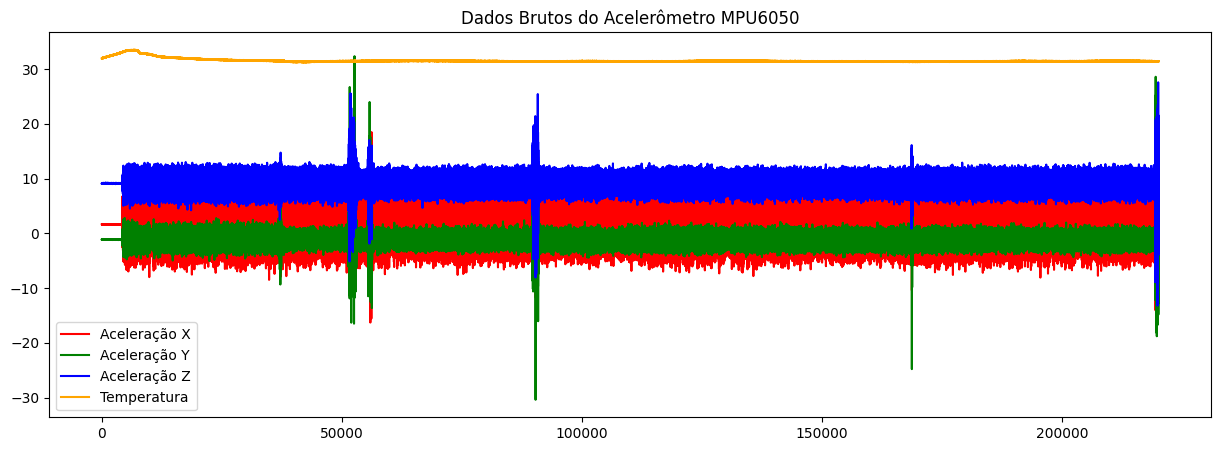

In [3]:
# @title Plotando os dados brutos

plt.figure(figsize=(15, 5))
plt.plot(df_raw_data['ax'], label='Aceleração X', color='red')
plt.plot(df_raw_data['ay'], label='Aceleração Y', color='green')
plt.plot(df_raw_data['az'], label='Aceleração Z', color='blue')
plt.plot(df_raw_data['temp'], label='Temperatura', color='orange')
plt.title('Dados Brutos do Acelerômetro MPU6050')
plt.legend()
plt.show()

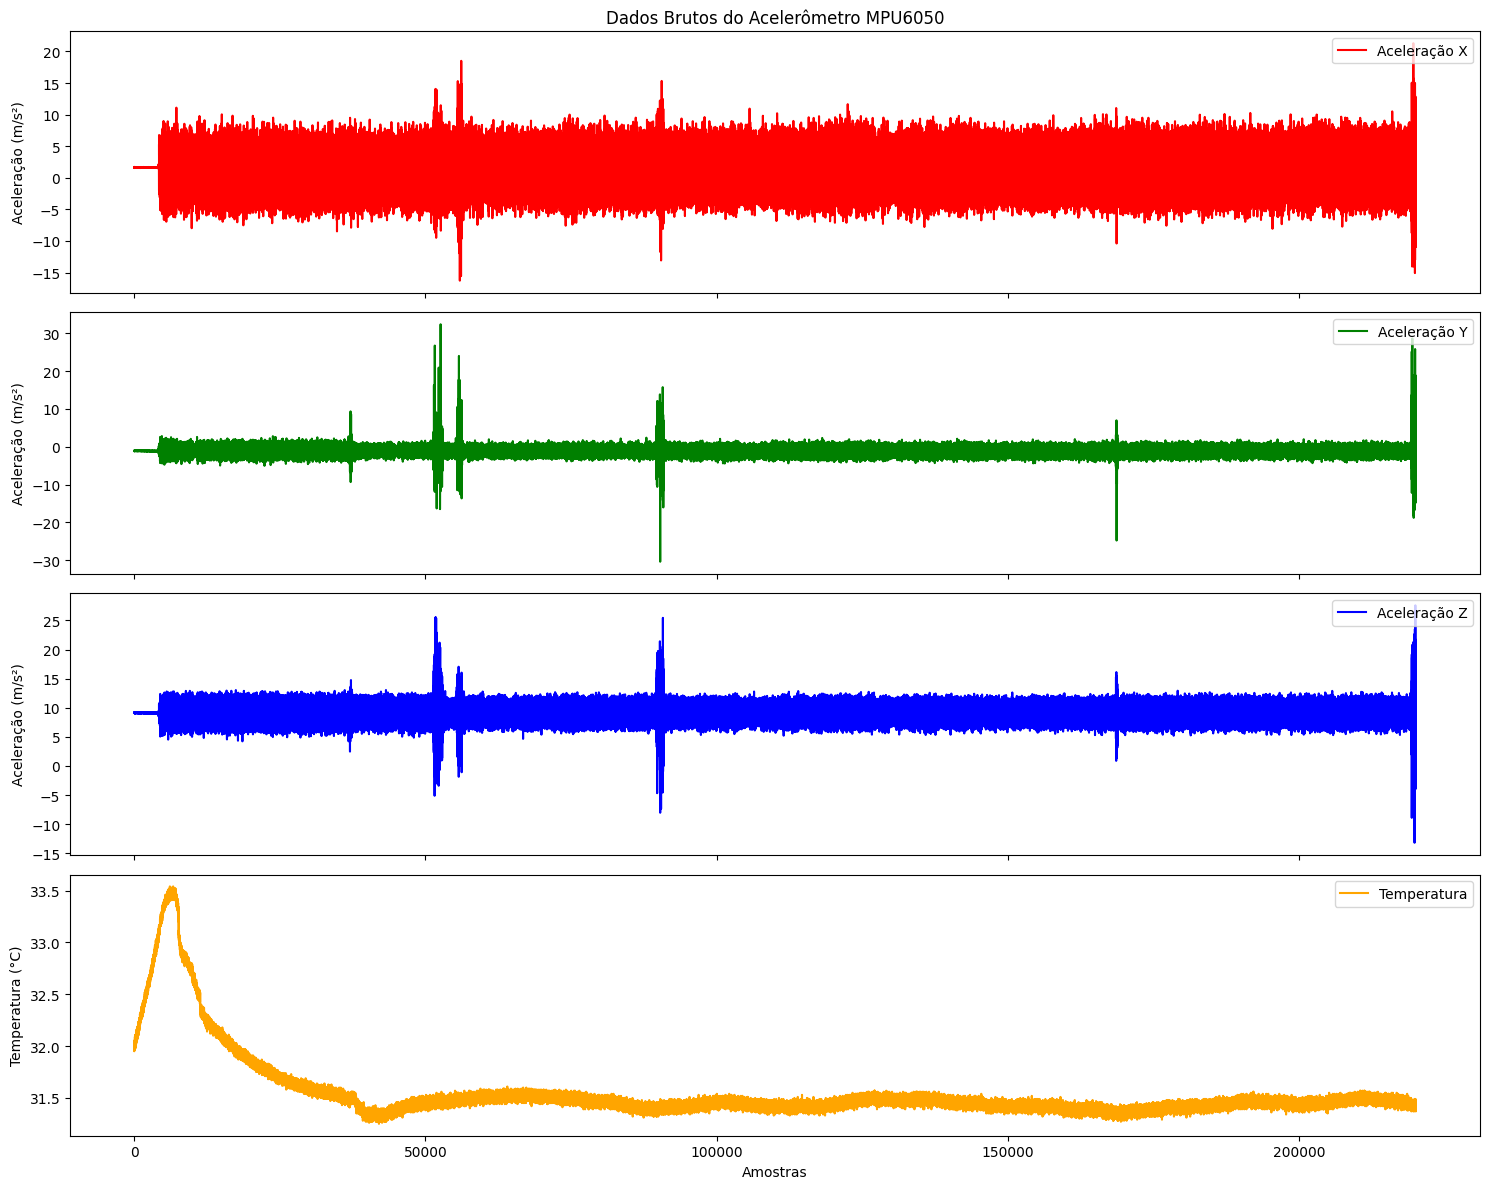

In [4]:
# @title Plotando os dados brutos separados

fig, axs = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Aceleração X
axs[0].plot(df_raw_data['ax'], label='Aceleração X', color='red')
axs[0].set_ylabel('Aceleração (m/s²)')
axs[0].legend(loc='upper right')
axs[0].set_title('Dados Brutos do Acelerômetro MPU6050')

# Aceleração Y
axs[1].plot(df_raw_data['ay'], label='Aceleração Y', color='green')
axs[1].set_ylabel('Aceleração (m/s²)')
axs[1].legend(loc='upper right')

# Aceleração Z
axs[2].plot(df_raw_data['az'], label='Aceleração Z', color='blue')
axs[2].set_ylabel('Aceleração (m/s²)')
axs[2].legend(loc='upper right')

# Temperatura
axs[3].plot(df_raw_data['temp'], label='Temperatura', color='orange')
axs[3].set_ylabel('Temperatura (°C)')
axs[3].set_xlabel('Amostras')
axs[3].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Análise por meio da Magnitude

Relembrando o funcionamento do ESP32, temos 1 segundo é representado por 100 amostras, dado que os dados foram extraídos a 100Hz.
<br>
Com isso em mente, separaremos em instantes de tempo para aplicar a Fast Furrier Transform (FFT) para transformar as variações de "frequência" em valores númericos, sem necessáriamente passar um vetor de alta dimensionalidade.


Antes de aplicar essa transformação dos dados, vamos criar uma feature de "magnitude" total da aceleração;


In [5]:
# @title Criando a feature de magnitude da aceleração

df_raw_data['acc_magnitude'] = np.sqrt(df_raw_data['ax']**2 + df_raw_data['ay']**2 + df_raw_data['az']**2)

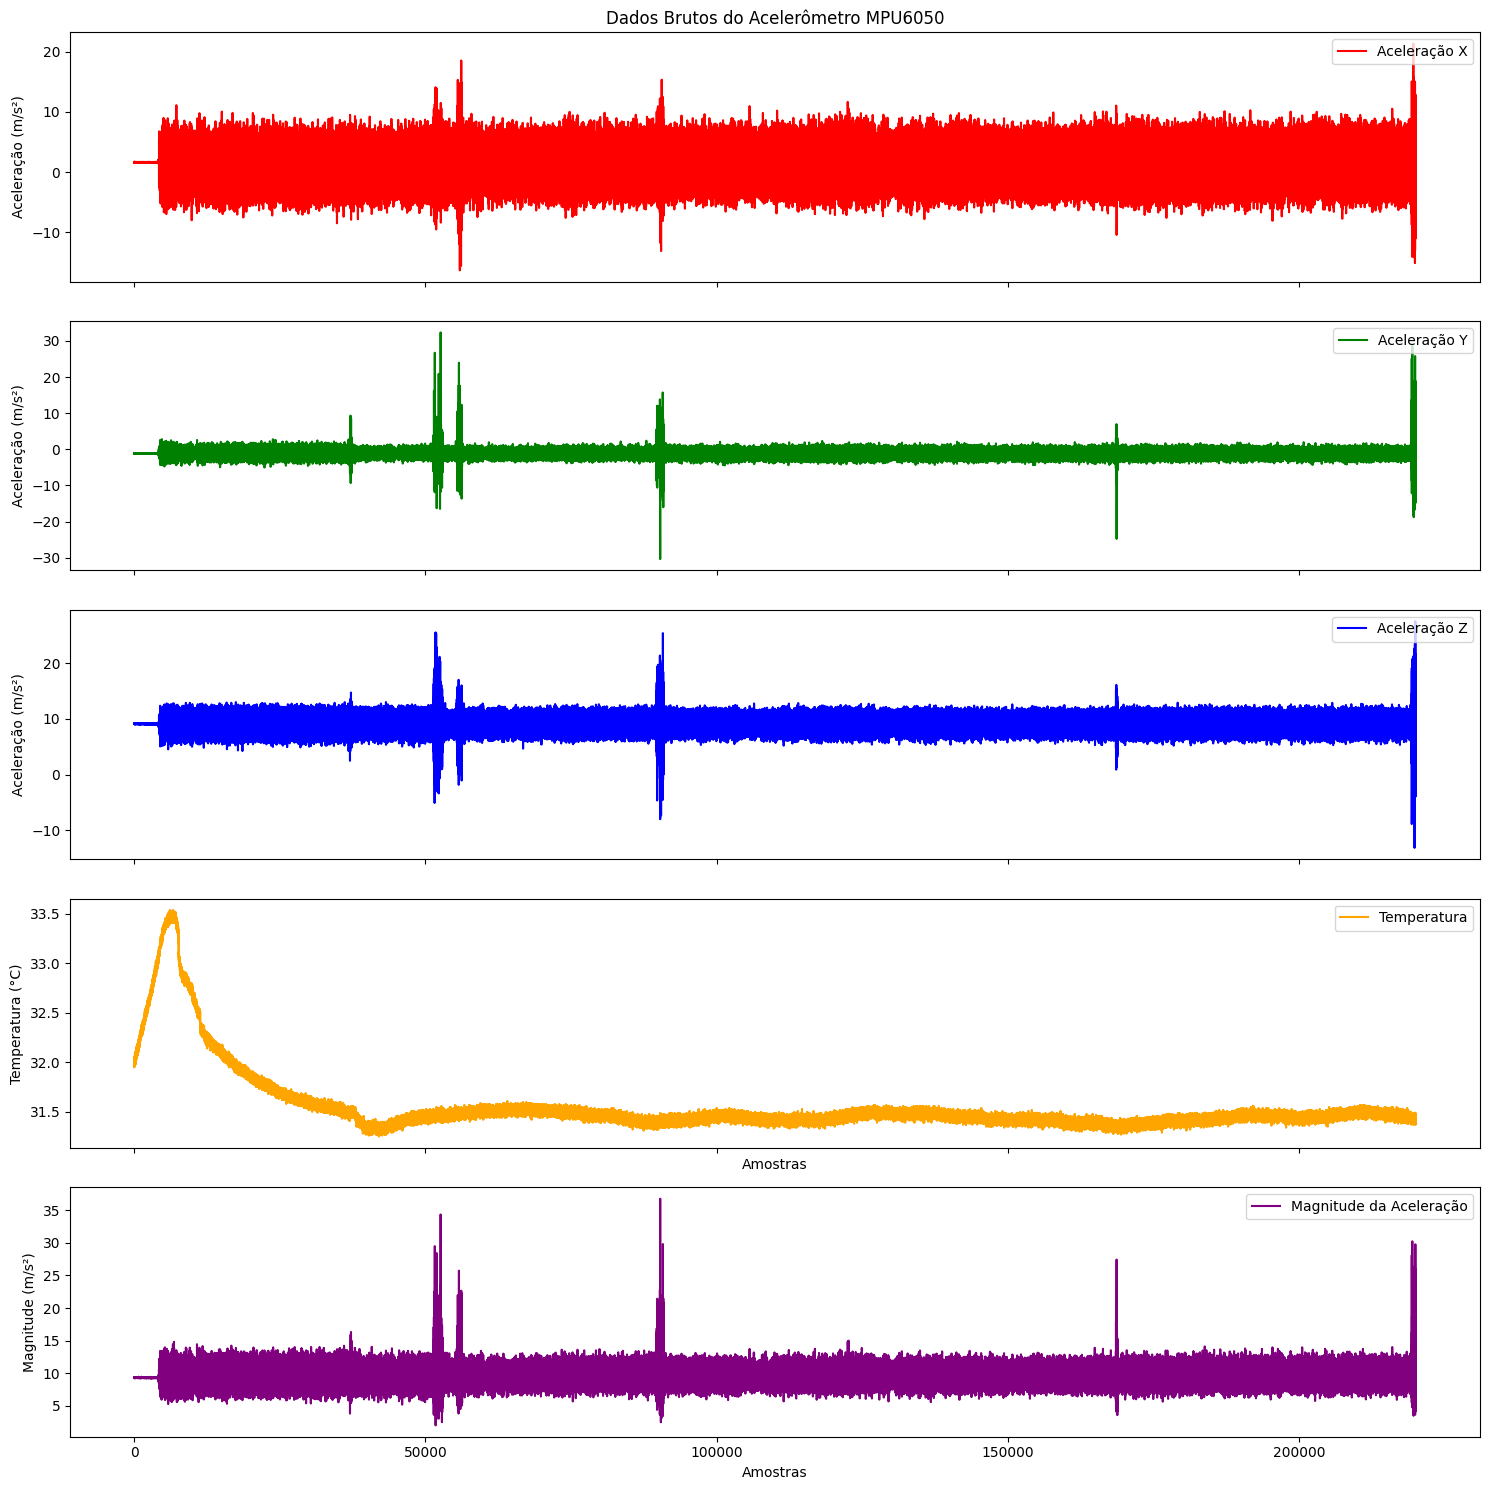

In [6]:
# @title Plotando a magnitude da aceleração

fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

# Aceleração X
axs[0].plot(df_raw_data['ax'], label='Aceleração X', color='red')
axs[0].set_ylabel('Aceleração (m/s²)')
axs[0].legend(loc='upper right')
axs[0].set_title('Dados Brutos do Acelerômetro MPU6050')

# Aceleração Y
axs[1].plot(df_raw_data['ay'], label='Aceleração Y', color='green')
axs[1].set_ylabel('Aceleração (m/s²)')
axs[1].legend(loc='upper right')

# Aceleração Z
axs[2].plot(df_raw_data['az'], label='Aceleração Z', color='blue')
axs[2].set_ylabel('Aceleração (m/s²)')
axs[2].legend(loc='upper right')

# Temperatura
axs[3].plot(df_raw_data['temp'], label='Temperatura', color='orange')
axs[3].set_ylabel('Temperatura (°C)')
axs[3].set_xlabel('Amostras')
axs[3].legend(loc='upper right')

# Magnitude da Aceleração
axs[4].plot(df_raw_data['acc_magnitude'], label='Magnitude da Aceleração', color='purple')
axs[4].set_ylabel('Magnitude (m/s²)')
axs[4].set_xlabel('Amostras')
axs[4].legend(loc='upper right')

plt.tight_layout()
plt.show()

Agora vamos expor histogramas e boxplots dos nossos resultados para verificar a distribuição de valores


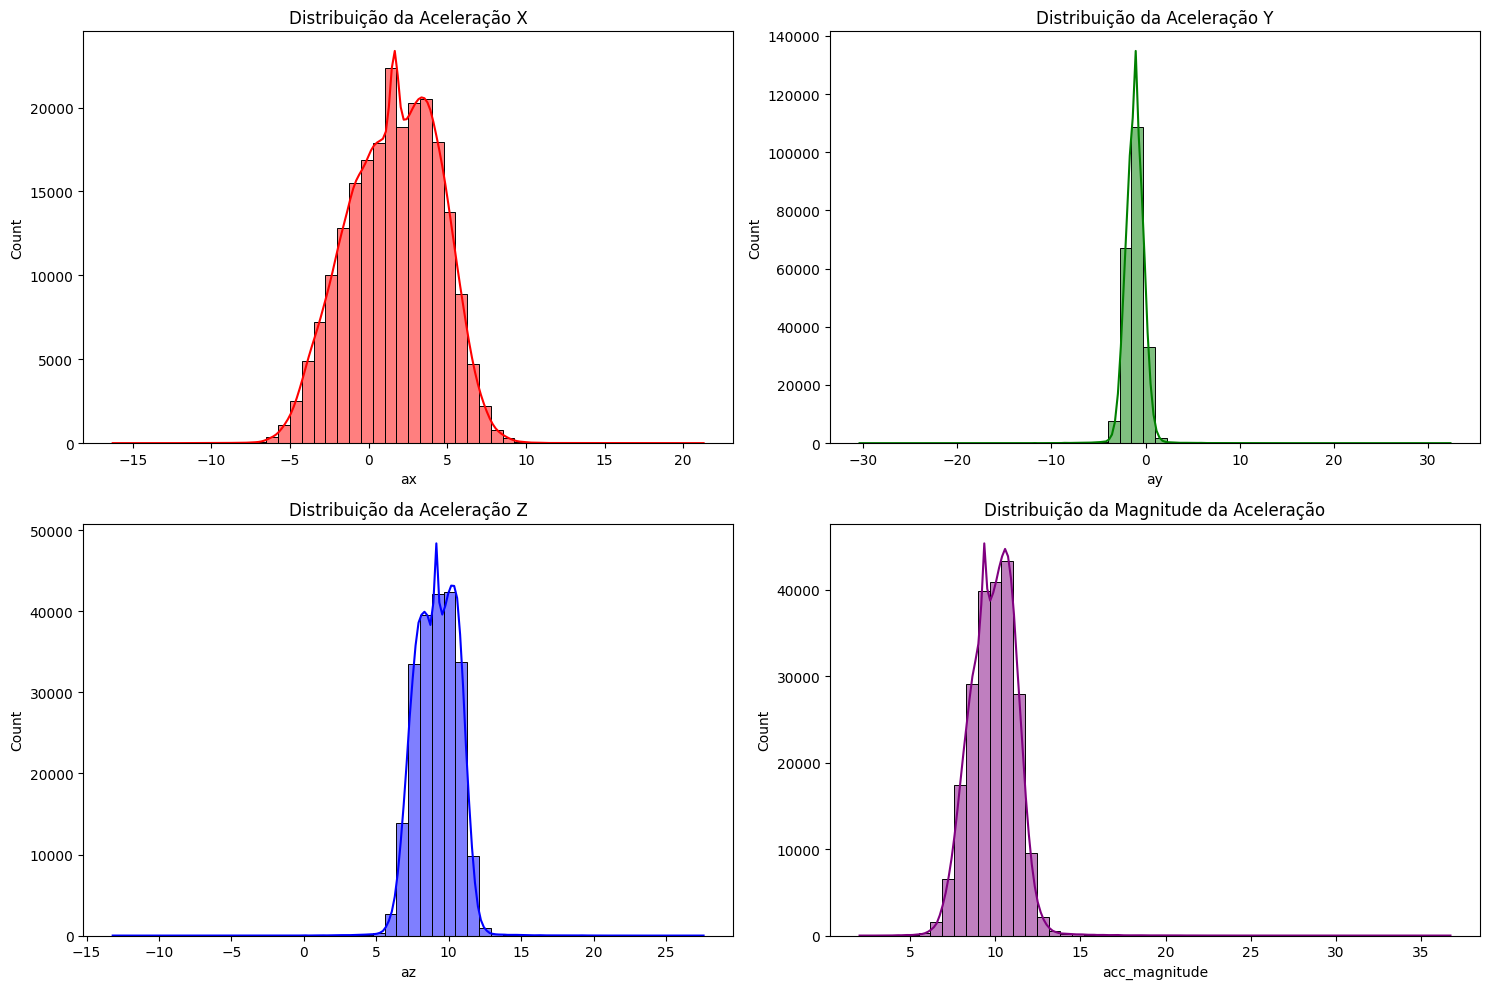

In [7]:
fig, axis = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df_raw_data['ax'], bins=50, kde=True, ax=axis[0, 0], color='red').set_title('Distribuição da Aceleração X')
sns.histplot(df_raw_data['ay'], bins=50, kde=True, ax=axis[0, 1], color='green').set_title('Distribuição da Aceleração Y')
sns.histplot(df_raw_data['az'], bins=50, kde=True, ax=axis[1, 0], color='blue').set_title('Distribuição da Aceleração Z')
sns.histplot(df_raw_data['acc_magnitude'], bins=50, kde=True, ax=axis[1, 1], color='purple').set_title('Distribuição da Magnitude da Aceleração')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Boxplot da Magnitude da Aceleração')

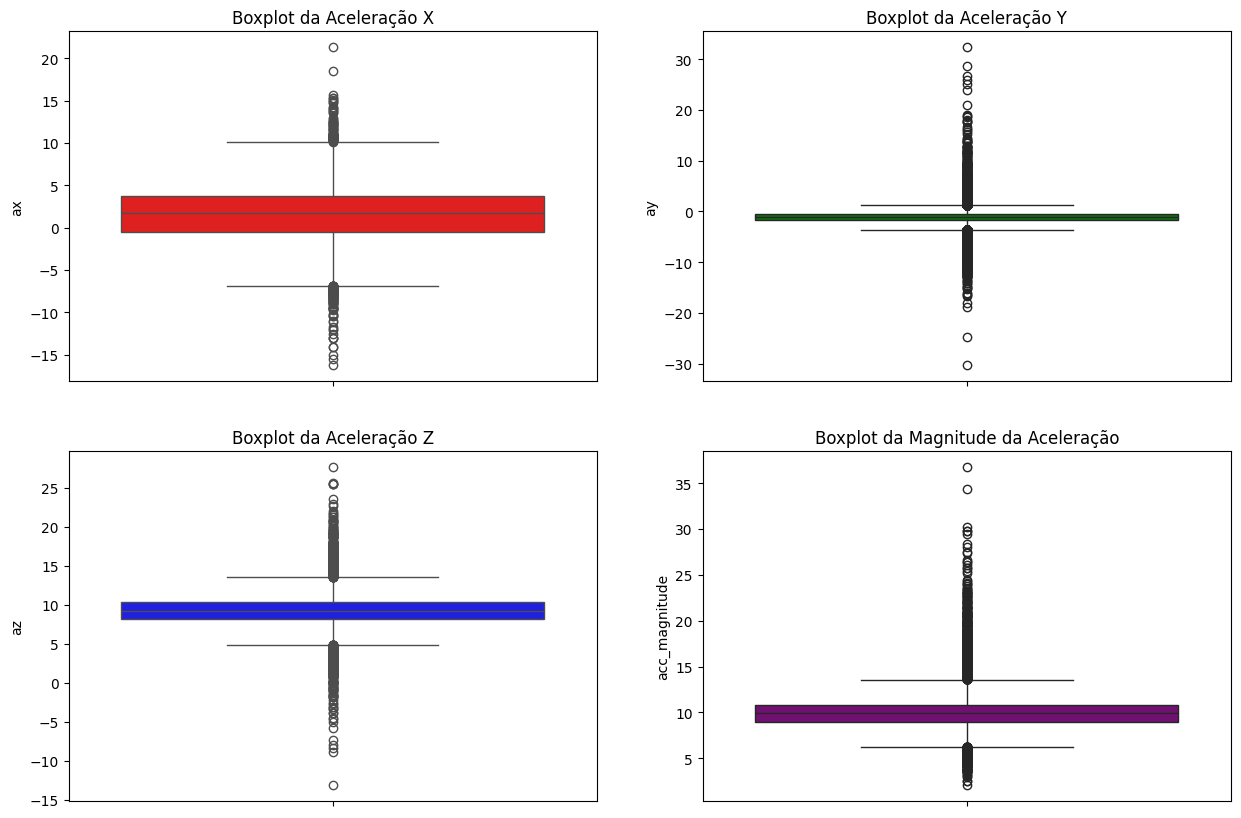

In [8]:
fig, axis = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(y=df_raw_data['ax'], ax=axis[0, 0], color='red').set_title('Boxplot da Aceleração X')
sns.boxplot(y=df_raw_data['ay'], ax=axis[0, 1], color='green').set_title('Boxplot da Aceleração Y')
sns.boxplot(y=df_raw_data['az'], ax=axis[1, 0], color='blue').set_title('Boxplot da Aceleração Z')
sns.boxplot(y=df_raw_data['acc_magnitude'], ax=axis[1, 1], color='purple').set_title('Boxplot da Magnitude da Aceleração')

Então, de acordo com a visualização das distribuições, podemos ver significativos outliers para cada feature detectada e até mesmo para a feature de magitude, que foi gerada.
<br>
Podemos ver que a aceleração em Y teve uma baixa amplitude, enquanto as acelerações em Z e X, principalmente, tiveram maor amplitude na sua distribuição, porém em Y e na magnitude a distância dos outliers para a mediana é mais significativa.


Assim, com a magnitude coletada, vamos aplicar a FFT ao longo das janelas de 100 amostras (1 segundo).


In [9]:
# @title Função para calcular a FFT em janelas móveis de N amostras de dados

def extract_fft_features(signal, fs, window_size, step_size=None):
    """
    signal: array 1D (ex: df_raw_data['acc_mag'].values)
    fs: frequência de amostragem (Hz)
    window_size: número de amostras por janela (ex: 100)
    step_size: quantas amostras andar a cada passo (default = window_size → janelas não sobrepostas)
    """
    if step_size is None:
        step_size = window_size
        
    features = []
    n_samples = len(signal)
        
    for start in range(0, n_samples - window_size + 1, step_size):
        end = start + window_size
        window = signal[start:end]
        
        window_detrended = window - np.mean(window) # A média aqui é subtraída para remover o componente DC, que é muito forte na maioria dos sinais de aceleração.
        
        fft_values = np.fft.rfft(window_detrended)
        fft_magnitudes = np.abs(fft_values)
        
        frequencies = np.fft.rfftfreq(window_size, d=1.0/fs)
        
        fft_magnitudes_without_dc = fft_magnitudes.copy()
        fft_magnitudes_without_dc[0] = 0  # Remover o componente 0 Hz (DC) para encontrar o pico correto
        
        
        # 1° Feature -> Frequência com o maior pico
        peak_idx = np.argmax(fft_magnitudes_without_dc)
        peak_frequency = frequencies[peak_idx]
        preak_magnitude = fft_magnitudes[peak_idx]
        
        # 2° Feature -> Energia total do espectro
        energy = np.sum(fft_magnitudes_without_dc**2)
        
        features.append({
            'start_index': start,
            'peak_frequency': peak_frequency,
            'peak_magnitude': preak_magnitude,
            'energy': energy
        })   
        
    return pd.DataFrame(features)
    
        
        
        

In [10]:
# @title Extraindo as features de FFT da magnitude da aceleração

signal = df_raw_data['acc_magnitude'].values # Valores da magnitude da aceleração
fs = 100  # Frequência de amostragem em Hz
window_size = 100  # Tamanho da janela em amostras (1 segundo)
step_size = 50  # Passo da janela em amostras (50% de sobreposição)

df_fft_features = extract_fft_features(signal, fs, window_size, step_size)
df_fft_features.head()


,start_index,peak_frequency,peak_magnitude,energy
0,0,19.0,0.712992,6.167201
1,50,17.0,0.805360,7.200306
2,100,33.0,0.944068,7.584410
3,150,32.0,0.884094,7.904368
4,200,10.0,0.768413,6.574533


Agora, com as features extraídas da FFT, vamos procurar outliers no conjunto de dados


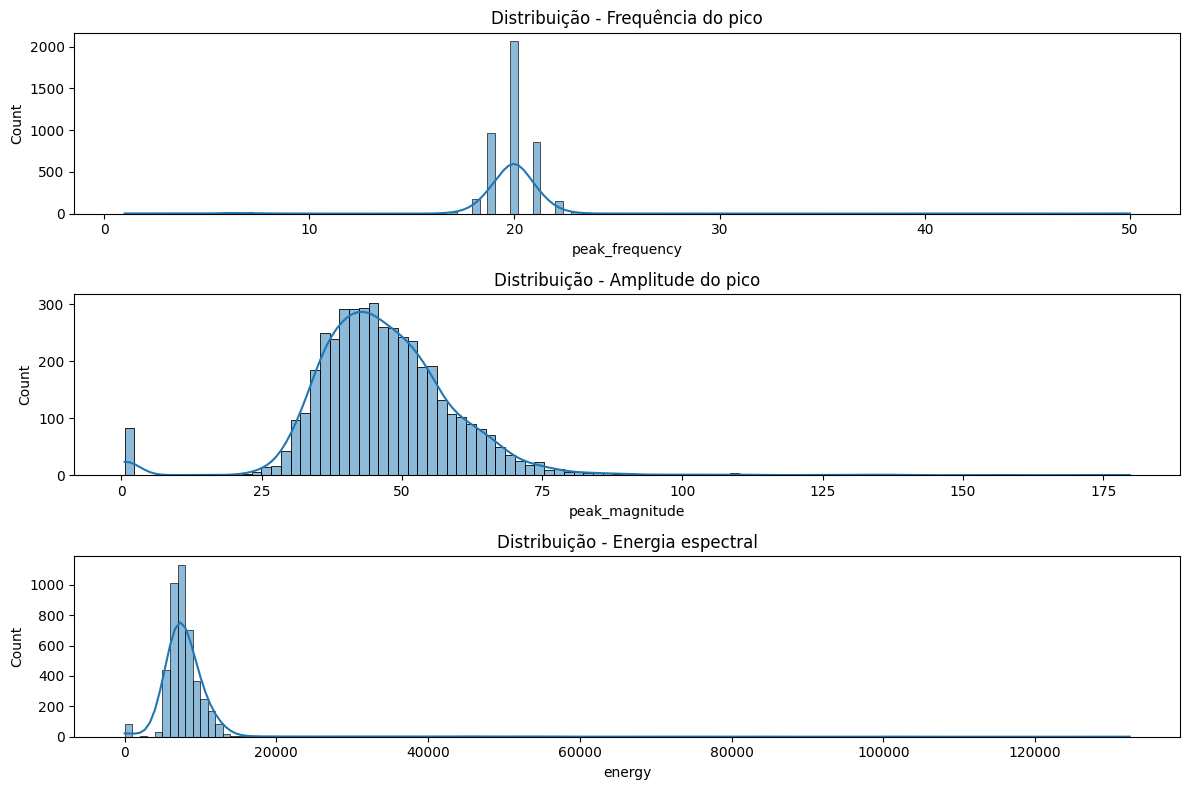

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(12, 8))

sns.histplot(df_fft_features["peak_frequency"], ax=axs[0], kde=True)
axs[0].set_title("Distribuição - Frequência do pico")

sns.histplot(df_fft_features["peak_magnitude"], ax=axs[1], kde=True)
axs[1].set_title("Distribuição - Amplitude do pico")

sns.histplot(df_fft_features["energy"], ax=axs[2], kde=True)
axs[2].set_title("Distribuição - Energia espectral")

plt.tight_layout()
plt.show()



Olhando as distribuições, temos a seguintes interpretações:

1. Na distrbuição de frequência, vemos que há uma grande concentração em torno de ~19-22 Hz, portanto essa seria a assinatura de saúde do motor em que a frequência está sendo estudada, os demais valores podem significar algumas coisas, como ruído, a frequência do motor ligando e desligando ou até mesmo outliers (anomalias);
2. Na distribuição da amplitude do pico, vemos uma cauda longa a direita, indicando janelas com picos mais fortes, nos mostrando que mesmo com o motor normal a intensidade varia ao longo do tempo, ainda há alguns ruidos, mudanças de posição, e essas janelas com amplitude mais alta podem indicar pancadas ou anomalias;
3. Na distribuição do espectro de energia, temos uma distribuição assimétrica, com uma concentração entre ~8k-22k, porém há uma cauda longa até valores entre ~60k-80k. Essa energia representa o quanto houve de vibração na janela, consistindo na soma dos quadrados da magnitude, ou seja, se a magnitude cresce em um determinado momento, a energia cresce mais ainda. Então, estes valores da cauda longa indicam algumas anomalias ao longo do tempo, devido os alto valores.


#### Modelo estatístico de detecção de anomalias

Considere que cada janela de 1 segundo do sinal gera duas _features_ principais:

- \( f_i \): frequência do pico (`peak_frequency`) na janela \(i\);
- \( E_i \): energia espectral total (`energy`) na janela \(i\).

#### 1. Cálculo das estatísticas da condição normal

Dado um conjunto de \( N \) janelas em condição **normal** (motor saudável), estimamos:

Média da frequência do pico:
\[
\mu*f = \frac{1}{N} \sum*{i=1}^{N} f_i
\]

Desvio-padrão da frequência do pico:
\[
\sigma*f = \sqrt{\frac{1}{N - 1} \sum*{i=1}^{N} (f_i - \mu_f)^2}
\]

Média da energia espectral:
\[
\mu*E = \frac{1}{N} \sum*{i=1}^{N} E_i
\]

Desvio-padrão da energia espectral:
\[
\sigma*E = \sqrt{\frac{1}{N - 1} \sum*{i=1}^{N} (E_i - \mu_E)^2}
\]

#### 2. Cálculo dos escores padronizados (z-score)

Para uma nova janela \( i \), calculamos o _z-score_ de cada feature:

\[
z\_{f,i} = \frac{f_i - \mu_f}{\sigma_f}
\]

\[
z\_{E,i} = \frac{E_i - \mu_E}{\sigma_E}
\]

#### 3. Combinação das features em um único escore de anomalia

Definimos um escore de anomalia combinado como:

\[
S*i = \sqrt{z*{f,i}^2 + z\_{E,i}^2}
\]

Esse escore cresce quando a frequência do pico ou a energia se afastam do comportamento normal.

#### 4. Regra de decisão (outlier)

Escolhemos um limiar \( \tau \) (por exemplo, \( \tau = 3 \) ou \( \tau = 4 \)).  
A janela \( i \) é considerada **anômala** se:

\[
S_i > \tau
\]

Caso contrário, ela é considerada **normal**:

\[
S_i \le \tau
\]


Visto este modelo estatistico para a identificação de outliers, implementar uma função para caracterizar essas anomalias e dar as suas labels


In [12]:
# @title Implementação da função para identificar anomalias estatísticas

def identificador_anomalias(df, threshold=3.0):
    df_out = df.copy()

    # --- Estatísticas globais ---
    mu_f = df_out["peak_frequency"].mean()
    sigma_f = df_out["peak_frequency"].std(ddof=1)

    mu_E = df_out["energy"].mean()
    sigma_E = df_out["energy"].std(ddof=1)

    # Evita divisão por zero (caso de variância muito baixa)
    if sigma_f == 0:
        sigma_f = 1e-9
    if sigma_E == 0:
        sigma_E = 1e-9

    # --- Z-scores ---
    df_out["z_peak_frequency"] = (df_out["peak_frequency"] - mu_f) / sigma_f
    df_out["z_energy"] = (df_out["energy"] - mu_E) / sigma_E

    # --- Score combinado S_i = sqrt(z_f^2 + z_E^2) ---
    df_out["anomaly_score"] = np.sqrt(
        df_out["z_peak_frequency"]**2 + df_out["z_energy"]**2
    )

    # --- Regra de decisão ---
    df_out["is_anomaly"] = df_out["anomaly_score"] > threshold

    return df_out

In [13]:
# @title Aplicação da função para identificar anomalias

df_fft_anom = identificador_anomalias(df_fft_features, threshold=3.0)
df_fft_anom.head()


,start_index,peak_frequency,peak_magnitude,energy,z_peak_frequency,z_energy,anomaly_score,is_anomaly
0,0,19.0,0.712992,6.167201,-0.294523,-1.037748,1.078733,False
1,50,17.0,0.805360,7.200306,-0.875773,-1.037625,1.357808,False
2,100,33.0,0.944068,7.584410,3.774227,-1.037579,3.914251,True
3,150,32.0,0.884094,7.904368,3.483602,-1.037541,3.634828,True
4,200,10.0,0.768413,6.574533,-2.910148,-1.037699,3.089625,True


In [14]:
# @title Contagem de anomalias estatísticas detectadas

df_fft_anom["is_anomaly"].value_counts()

is_anomaly
False    4245
True      154
Name: count, dtype: int64

Plotando o sinal e vendo as anomalias detectadas ao longo do tempo


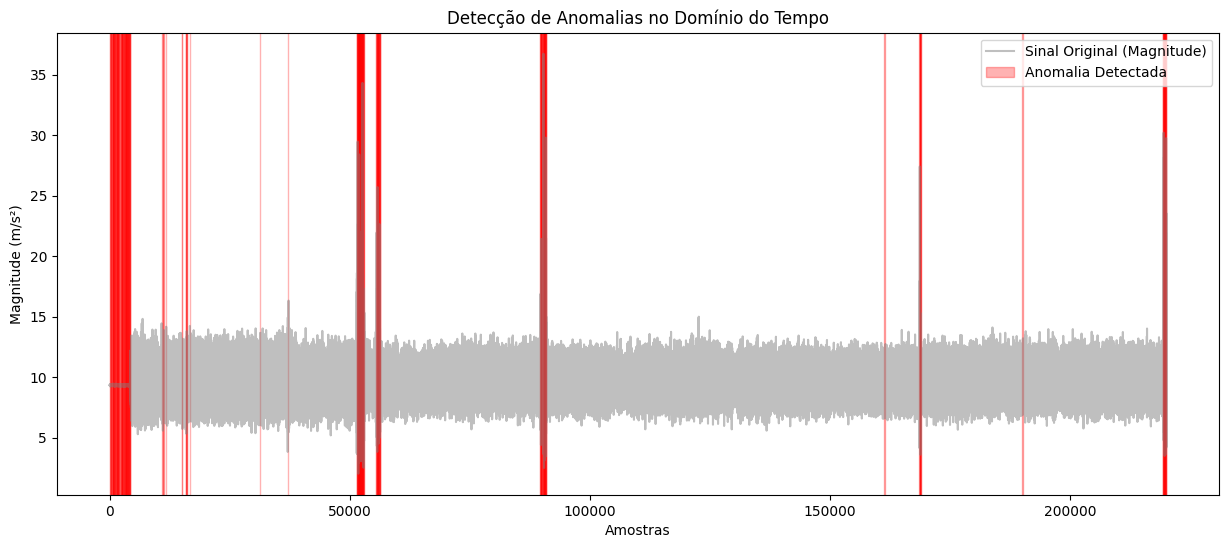

In [15]:
# @title Visualização das Anomalias no Tempo

plt.figure(figsize=(15, 6))

# Plot do sinal original (Magnitude)
plt.plot(df_raw_data['acc_magnitude'], color='gray', alpha=0.5, label='Sinal Original (Magnitude)')

# Destacar as janelas anômalas
# window_size foi definido anteriormente como 100
anomalies = df_fft_anom[df_fft_anom['is_anomaly'] == True]

# Flag para legenda
first_anomaly = True

for _, row in anomalies.iterrows():
    start = int(row['start_index'])
    end = start + window_size
    
    if first_anomaly:
        plt.axvspan(start, end, color='red', alpha=0.3, label='Anomalia Detectada')
        first_anomaly = False
    else:
        plt.axvspan(start, end, color='red', alpha=0.3)

plt.title('Detecção de Anomalias no Domínio do Tempo')
plt.xlabel('Amostras')
plt.ylabel('Magnitude (m/s²)')
plt.legend(loc='upper right')
plt.show()

### Análise por meio do Sinal de Frequência

Após a análise por meio da magnitude geral do sinal, vamos olhar a frequência pura, gerando θ a partir da aplicação da FFT em <code>ax</code>,<code>ay</code> e <code>az</code>.
<br>
Vamos recorrer a este método devido o problema de que a transformação em magnitude exclui valores negativos (raiz da soma dos **qudrados**). Portanto, vamos aplicar a FFT direto no sinal de frequência emitido ao longo do tempo.


In [16]:
# @title Extração de Features FFT por Eixo (X, Y, Z)

axes = ['ax', 'ay', 'az'] # Eixos a serem processados separadamente
dfs_axes = []

# Parâmetros (mesmos usados anteriormente)
fs = 100
window_size = 100
step_size = 50

for axis in axes:
    print(f"Processando eixo: {axis}...")
    signal = df_raw_data[axis].values
    
    # Reutiliza a função que você já criou
    df_feat = extract_fft_features(signal, fs, window_size, step_size)
    
    # Renomeia as colunas para identificar o eixo (ex: ax_peak_frequency)
    df_feat.columns = [f"{axis}_{col}" if col != 'start_index' else col for col in df_feat.columns]
    
    # Define o start_index como índice para facilitar o merge
    df_feat.set_index('start_index', inplace=True)
    dfs_axes.append(df_feat)

# Concatena tudo em um único DataFrame (axis=1 para juntar colunas)
df_fft_axes = pd.concat(dfs_axes, axis=1)
df_fft_axes.reset_index(inplace=True)

print("Extração concluída!")
df_fft_axes.head()

Processando eixo: ax...
Processando eixo: ay...
Processando eixo: az...
Extração concluída!


,start_index,ax_peak_frequency,ax_peak_magnitude,ax_energy,ay_peak_frequency,ay_peak_magnitude,ay_energy,az_peak_frequency,az_peak_magnitude,az_energy
0,0,3.0,1.309595,5.3088,3.0,1.212414,4.9824,19.0,0.761700,6.2000
1,50,3.0,0.674445,4.8670,3.0,1.031561,4.5824,17.0,0.818896,7.2436
2,100,38.0,0.648463,3.9508,2.0,0.566623,3.7250,33.0,0.990893,7.6802
3,150,3.0,0.595642,3.0418,4.0,0.596380,3.1472,32.0,0.827778,7.6450
4,200,44.0,0.426333,2.9946,37.0,0.600844,3.3494,10.0,0.764421,6.3430


Assim, aplicando a FFT em cada eixo nos dá sensibilidade direcional.
<br>
Esta sensibilidade nos ajuda a indicar se o motor está "solto", olhando os níveis de energia em cada eixo separadamente, onde a magnitude "misturava" e "comprimia" tudo isso.
<br>
Caso seja um "empenamento", a o sinal da vibração tende a se mostrar em uma direção específica.
<br>
<br>
Junto a isso, o fato da FFT trabalhar com ondas, ela usa o sinal, negativo ou positivo, para definir a fase da onda, o que era perdido com o cálculo de magnitude, que excluia valores negativos e poderia ocasionar em "frequências fantasmas" que não existem de fato no motor, sendo artefatos das raizes quadradas.
<br>
Então, trabalhando puramente com os valores dos eixos, nos dá mais uma clareza espectral.


Com as features extraídas, vamos dar uma olhada na "cara" destes dados:


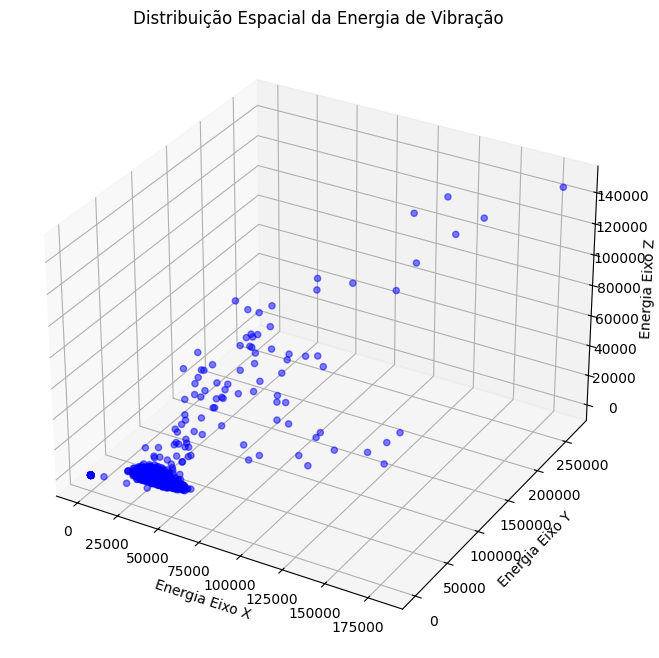

In [17]:
# @title Visualização 3D das Energias por Eixo

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotando a Energia de X vs Y vs Z
ax.scatter(df_fft_axes['ax_energy'], 
           df_fft_axes['ay_energy'], 
           df_fft_axes['az_energy'], 
           c='blue', marker='o', alpha=0.5)

ax.set_xlabel('Energia Eixo X')
ax.set_ylabel('Energia Eixo Y')
ax.set_zlabel('Energia Eixo Z')
plt.title('Distribuição Espacial da Energia de Vibração')
plt.show()

Olhando a distribuição de energia ao longo dos eixos, percebemos uma alta concentração em valores de baixa energia em X, energia ~baixa-intermediária em Z e alta energia em Y, com alguns poucos valores que fogem destepadrão, indicando possíveis anomalias.


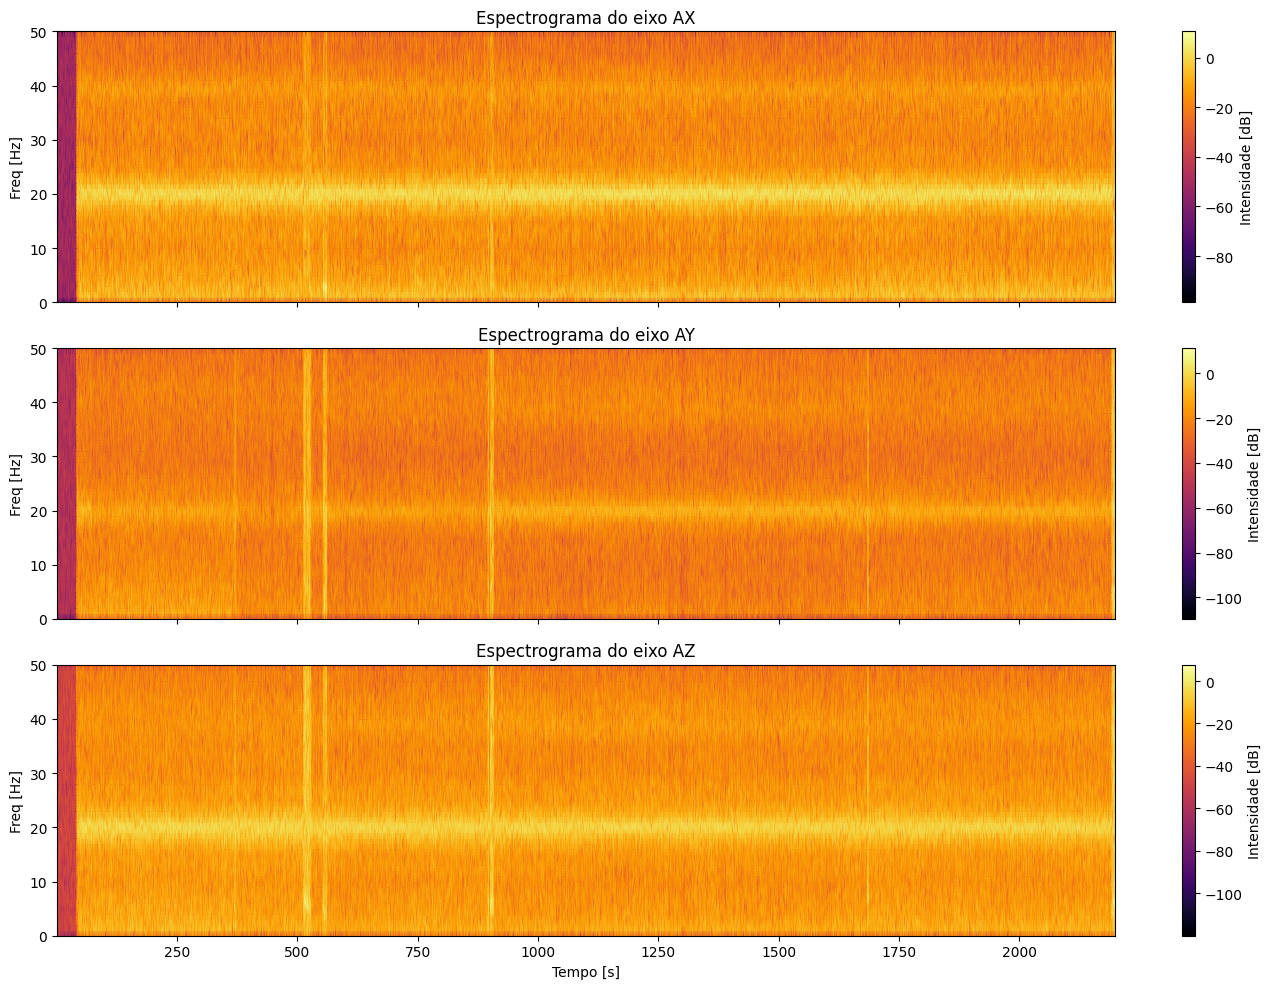

In [18]:
from scipy.signal import spectrogram
import numpy as np
import matplotlib.pyplot as plt

fs = 100  # Hz
eixos = ["ax", "ay", "az"]

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax_plot, eixo in zip(axs, eixos):
    f, t, Sxx = spectrogram(
        df_raw_data[eixo].values,
        fs=fs,
        nperseg=100,
        noverlap=50
    )

    # soma um epsilon pra evitar log10(0)
    pcm = ax_plot.pcolormesh(
        t, f, 10 * np.log10(Sxx + 1e-12),
        shading="gouraud",
        cmap="inferno"
    )

    ax_plot.set_ylabel("Freq [Hz]")
    ax_plot.set_title(f"Espectrograma do eixo {eixo.upper()}")

    fig.colorbar(pcm, ax=ax_plot, label="Intensidade [dB]")

axs[-1].set_xlabel("Tempo [s]")
plt.tight_layout()
plt.show()


### Construção de um Modelo de Regressão Logistica

Agora, com base na extração de labels, a partir do modelo estatistico _z-score_, gerando a coluna de <code>is*anomaly</code>, vamos implementar um modelo de aprendizado de máquina de \_Regressão Logistica* que vai receber como entrada alguns números por window, utilizar uma função de utilidade, que estima a probabilidade de ser uma anomalia ou não, aplicar a função sigmoide :
<code>

$$
\begin{align*}
p &= \frac{1}{1 + e^{-z}} \\
\\
\text{Onde } p \text{ é a probabilidade de "anomalia".} \\
\\
\text{Resultado} &= \begin{cases}
   \text{Anomalia (label 1)}, & \text{se } p > 0.5 \\
   \text{Normal (label 0)}, & \text{se } p \le 0.5
\end{cases}
\end{align*}
$$

</code>


Vamos usar como dado o Dataframe _df_fft_anom_, o qual contém as labels <code>is_anomaly</code>


In [19]:
# @title Nomeando os dados para modelagem

feature_cols = ["peak_frequency", "energy"]

x = df_fft_anom[feature_cols].values # Features
y = df_fft_anom["is_anomaly"].astype(int).values # Labels

In [20]:
# @title Imports para Modelagem

%pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 4.2 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 11.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [21]:
# @title Separando o conjunto de testes e o de treino

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2, # Conjunto de testes = 20%
    random_state=42, # Reprodutibilidade
    stratify=y # Mantém a proporção de classes
)

In [22]:
# @title Montando o Pipeline de Modelagem e Treinamento

# Pipeline do modelo
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])


# Treinando o modelo
logreg_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [23]:
# @title Avaliando o modelo

y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1] # Probabilidade da classe positiva (anômalo)

In [24]:
# @title Relatório de Classificação

print(classification_report(y_test, y_pred, target_names=['Normal', 'Anômalo']))

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       849
     Anômalo       0.79      0.71      0.75        31

    accuracy                           0.98       880
   macro avg       0.89      0.85      0.87       880
weighted avg       0.98      0.98      0.98       880



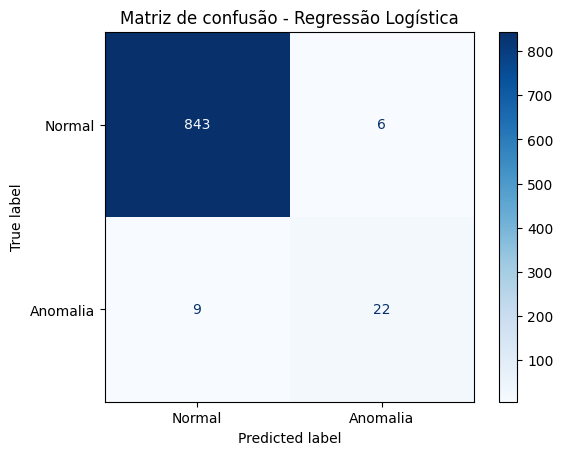

In [25]:
# @title Matriz de Confusão

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomalia"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusão - Regressão Logística")
plt.show()


In [26]:
# @title Modelo Puro

logreg = logreg_pipeline.named_steps["model"]
scaler = logreg_pipeline.named_steps["scaler"]

print("Coeficientes:", logreg.coef_)
print("Intercepto:", logreg.intercept_)
print("Médias usadas no scaler:", scaler.mean_)
print("Desvios usados no scaler:", scaler.scale_)
print("Features na ordem:", feature_cols)


Coeficientes: [[0.35955423 0.96707036]]
Intercepto: [-0.75556951]
Médias usadas no scaler: [  20.04262575 8737.57146521]
Desvios usados no scaler: [3.43938731e+00 8.54702116e+03]
Features na ordem: ['peak_frequency', 'energy']
